# Malaysia Grocery Price Index

Initial exploration of PriceCatcher observations for August 2022 and August 2026.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
items = pd.read_csv("../data/lookup_item.csv")
premises = pd.read_csv("../data/lookup_premise.csv")

df22 = pd.read_csv("../data/pricecatcher_2022-08.csv")
df26 = pd.read_csv("../data/pricecatcher_2026-08.csv")

# Merge
df22 = df22.merge(items, on="item_code", how="left").merge(premises, on="premise_code", how="left")
df26 = df26.merge(items, on="item_code", how="left").merge(premises, on="premise_code", how="left")

print(f"2022: {df22.shape[0]:,} rows")
print(f"2026: {df26.shape[0]:,} rows")
print(f"\nStates 2022: {df22['state'].nunique()}")
print(f"States 2026: {df26['state'].nunique()}")

# Basket definition
basket = {
    "Ayam bersih 1kg": 1,
    "Telur ayam Gred A (30 biji)": 1109,
    "Beras 10kg": 904,
    "Minyak masak 1kg": 918,
    "Gula putih 1kg": 1590,
    "Ikan kembung 1kg": 1476,
    "Kangkung 1kg": 1559,
    "Tomato 1kg": 114,
    "Bawang besar 1kg": 1440,
    "Cili merah 1kg": 94,
}

print(f"\nBasket items: {len(basket)}")
df22.head()

2022: 2,664,356 rows
2026: 1,933,285 rows

States 2022: 16
States 2026: 16

Basket items: 10


,date,premise_code,item_code,price,item,unit,item_group,item_category,premise,address,premise_type,state,district
0,2022-08-01,2,1,9.4,AYAM BERSIH - STANDARD,1kg,BARANGAN SEGAR,AYAM,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta
1,2022-08-01,2,9,36.0,DAGING KAMBING BEBIRI IMPORT BERTULANG (MUTTON...,1kg,BARANGAN SEGAR,DAGING,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta
2,2022-08-01,2,16,3.5,BETIK BIASA,1kg,BARANGAN SEGAR,BUAH-BUAHAN,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta
3,2022-08-01,2,18,5.0,PISANG BERANGAN,1kg,BARANGAN SEGAR,BUAH-BUAHAN,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta
4,2022-08-01,2,19,5.0,PISANG EMAS,1kg,BARANGAN SEGAR,BUAH-BUAHAN,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta


In [3]:
# Peninsular states only (East Malaysia missing beras data)
peninsular = [
    "Johor","Kedah","Kelantan","Melaka","Negeri Sembilan",
    "Pahang","Perak","Perlis","Pulau Pinang","Selangor",
    "Terengganu","W.P. Kuala Lumpur","W.P. Putrajaya"
]

def basket_by_state(df, states):
    results = []
    for item_name, code in basket.items():
        state_prices = (df[df["item_code"]==code]
                        .groupby("state")["price"]
                        .median()
                        .reset_index())
        state_prices["item"] = item_name
        results.append(state_prices)
    pivot = (pd.concat(results)
             .pivot(index="state", columns="item", values="price"))
    pivot["TOTAL"] = pivot.sum(axis=1)
    return pivot.loc[pivot.index.isin(states)]

b22 = basket_by_state(df22, peninsular)
b26 = basket_by_state(df26, peninsular)

# State comparison
comp = pd.DataFrame({
    "Aug 2022 (RM)": b22["TOTAL"],
    "Aug 2026 (RM)": b26["TOTAL"],
})
comp["Naik (RM)"] = (comp["Aug 2026 (RM)"] - comp["Aug 2022 (RM)"]).round(2)
comp["Naik (%)"] = (comp["Naik (RM)"] / comp["Aug 2022 (RM)"] * 100).round(1)
comp = comp.sort_values("Naik (%)", ascending=False).round(2)

print("BASKET: Aug 2022 vs Aug 2026")
print(comp.to_string())

# Item level national
print("\nITEM-LEVEL CHANGE (national median):")
item_comp = []
for name, code in basket.items():
    p22 = df22[df22["item_code"]==code]["price"].median()
    p26 = df26[df26["item_code"]==code]["price"].median()
    item_comp.append({
        "item": name,
        "Aug 2022": p22,
        "Aug 2026": p26,
        "change_rm": round(p26-p22, 2),
        "change_pct": round((p26-p22)/p22*100, 1)
    })

item_df = pd.DataFrame(item_comp).sort_values("change_pct", ascending=False)
print(item_df.to_string(index=False))

BASKET: Aug 2022 vs Aug 2026
                   Aug 2022 (RM)  Aug 2026 (RM)  Naik (RM)  Naik (%)
state                                                               
W.P. Kuala Lumpur         107.22         118.11      10.89      10.2
Pahang                    105.02         115.10      10.08       9.6
Negeri Sembilan           105.30         114.79       9.49       9.0
W.P. Putrajaya            111.40         120.57       9.16       8.2
Johor                     105.90         113.90       8.00       7.6
Melaka                    104.92         112.25       7.33       7.0
Perlis                    105.14         112.15       7.01       6.7
Selangor                  108.31         115.38       7.07       6.5
Pulau Pinang              103.63         109.81       6.18       6.0
Perak                     101.82         107.30       5.48       5.4
Terengganu                108.04         113.88       5.84       5.4
Kedah                     101.42         106.74       5.32       5.2
Kelan

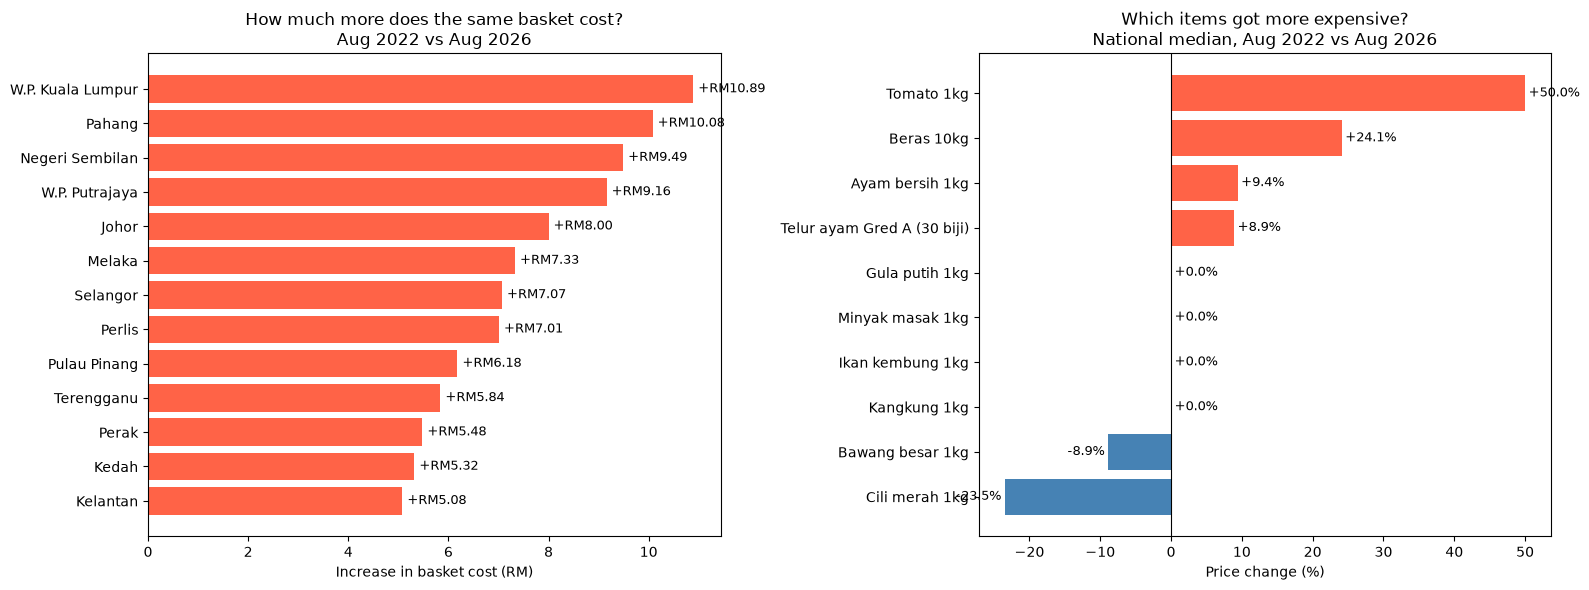

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — basket by state
comp_sorted = comp.sort_values("Naik (RM)")
colors = ["tomato" if x > 0 else "steelblue" for x in comp_sorted["Naik (RM)"]]
axes[0].barh(comp_sorted.index, comp_sorted["Naik (RM)"], color="tomato")
axes[0].set_xlabel("Increase in basket cost (RM)")
axes[0].set_title("How much more does the same basket cost?\nAug 2022 vs Aug 2026")
for i, (state, row) in enumerate(comp_sorted.iterrows()):
    axes[0].text(row["Naik (RM)"] + 0.1, i, f'+RM{row["Naik (RM)"]:.2f}', va="center", fontsize=9)

# Chart 2 — item level change
item_sorted = item_df.sort_values("change_pct")
colors2 = ["tomato" if x > 0 else "steelblue" for x in item_sorted["change_pct"]]
axes[1].barh(item_sorted["item"], item_sorted["change_pct"], color=colors2)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Price change (%)")
axes[1].set_title("Which items got more expensive?\nNational median, Aug 2022 vs Aug 2026")
for i, row in enumerate(item_sorted.itertuples()):
    label = f'{row.change_pct:+.1f}%'
    x = row.change_pct + 0.5 if row.change_pct >= 0 else row.change_pct - 0.5
    ha = "left" if row.change_pct >= 0 else "right"
    axes[1].text(x, i, label, va="center", fontsize=9, ha=ha)

plt.tight_layout()
plt.show()